# 14: robustness is the reweighted statistic

Claims:

1. The plain block fit carries no robustness of its own: under scattered
   outliers it lands within a quarter of plain least squares and of the
   plain Legendre fit. False if any plain row separates from the others by
   more than that.
2. Reweighting the image is what works, in either basis: at 10 percent
   contamination the robust rows are below a third of their plain
   counterparts. False if a robust row is not clearly below its plain one.
3. The block basis loses a burst as its windows grow narrower than the
   burst, and no window count beats Legendre there. False if the
   narrow-window block fit matches Legendre under the longest burst.
4. Reweighting costs little on clean data, read on the fitted curve's RMSE
   against the truth: over blocks of 60 clean draws the robust fit's
   pooled RMSE stays within a tenth of the plain fit's in either basis,
   and about half the draws in a block put the robust fit below the plain
   one. False if reweighting costs more than 15 percent of the curve RMSE
   in a block.


In [1]:
import os
import time

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from dtfit.image import Original, fit
from dtfit_experimental.study import baselines as bl
from dtfit_experimental.study import families as F
from dtfit_experimental.study import montecarlo, notebook

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110
notebook.plain_warnings()

FAMILY = next(f for f in F.FAMILIES if f.key == "gauss")
LEG_ORDER, BLOCK_ORDER = 12, 48
SEEDS = 8 if QUICK else 30
FRACTIONS = [0.0, 0.10] if QUICK else [0.0, 0.05, 0.10, 0.20]
BURSTS = [1, 20] if QUICK else [1, 5, 10, 20, 40]
WINDOW_COUNTS = [8, 48] if QUICK else [4, 8, 16, 48]
print(f"QUICK={QUICK} SEEDS={SEEDS} FRACTIONS={FRACTIONS} BURSTS={BURSTS} "
      f"WINDOW_COUNTS={WINDOW_COUNTS}")


QUICK=False SEEDS=30 FRACTIONS=[0.0, 0.05, 0.1, 0.2] BURSTS=[1, 5, 10, 20, 40] WINDOW_COUNTS=[4, 8, 16, 48]


## The scattered sweep

`study.families`'s Gaussian peak (spectroscopy, `A*exp(-(t-mu)**2/(2*s**2))`,
`n=300`, base noise 5 percent of the signal's range) contaminated by
`montecarlo.contaminate` at `magnitude=8.0` and the default `sigma` (the
sample standard deviation of the noisy signal), in single-sample runs
(`burst=1`). Six estimators: plain NLLS, pointwise robust NLLS (`soft_l1`),
plain Legendre (order 12), robust Legendre, plain block (48 windows), robust
block. `dtfit.fit`'s `p0`/`bounds` go in as name-keyed mappings so the
sympy-sorted coefficient order never has to be tracked by hand; the score is
`study.families.param_error`, the median relative parameter error in
percent.


In [2]:
NAMES = FAMILY.names
P0 = dict(zip(NAMES, FAMILY.p0))
BOUNDS = dict(zip(NAMES, FAMILY.bounds))
LO = np.array([b[0] for b in FAMILY.bounds])
HI = np.array([b[1] for b in FAMILY.bounds])


def draw(rng, n, noise, fraction, burst):
    x, y, clean = F.simulate(FAMILY, rng, n=n, noise=noise)
    y, idx = montecarlo.contaminate(y, rng=rng, fraction=fraction,
                                     magnitude=8.0, burst=burst)
    return x, y, idx


def est_nlls(x, y):
    p = bl.scipy_curve_fit(x, y, FAMILY.func, FAMILY.p0, bounds=(LO, HI))
    return dict(zip(NAMES, p))


def est_soft_l1(x, y):
    p = bl.robust_curve_fit(x, y, FAMILY.func, FAMILY.p0, bounds=(LO, HI),
                             loss="soft_l1")
    return dict(zip(NAMES, p))


def est_dt(x, y, basis, order, robust):
    r = fit(FAMILY.expr, Original(x, y), FAMILY.var, basis=basis,
            order=order, p0=P0, bounds=BOUNDS, robust=robust)
    return r.params


LADDER = [
    ("NLLS", lambda x, y: est_nlls(x, y)),
    ("soft_l1 (pointwise)", lambda x, y: est_soft_l1(x, y)),
    ("Legendre", lambda x, y: est_dt(x, y, "legendre", LEG_ORDER, False)),
    ("Legendre robust", lambda x, y: est_dt(x, y, "legendre", LEG_ORDER, True)),
    ("block", lambda x, y: est_dt(x, y, "block", BLOCK_ORDER, False)),
    ("block robust", lambda x, y: est_dt(x, y, "block", BLOCK_ORDER, True)),
]

rows = []
for fraction in FRACTIONS:
    for name, estimator in LADDER:
        errs = []
        for s in range(SEEDS):
            rng = np.random.default_rng(s)
            x, y, _ = draw(rng, 300, 0.05, fraction, 1)
            try:
                errs.append(F.param_error(estimator(x, y), FAMILY))
            except Exception:
                errs.append(np.nan)
        rows.append({"estimator": name, "fraction": fraction,
                      "param_error_pct": float(np.nanmedian(errs))})
outlier_sweep = pd.DataFrame(rows)
outlier_sweep.pivot(index="estimator", columns="fraction",
                     values="param_error_pct").loc[[n for n, _ in LADDER]]


fraction,0.00,0.05,0.10,0.20
estimator,,,,
NLLS,0.401931,4.876993,5.296509,8.799386
soft_l1 (pointwise),0.394094,0.486309,0.646817,0.895886
Legendre,0.397937,4.865162,5.114697,8.811134
Legendre robust,0.402886,0.410608,0.437249,0.408051
block,0.437680,5.092977,4.769695,8.338640
block robust,0.359000,0.398747,0.454079,0.652694


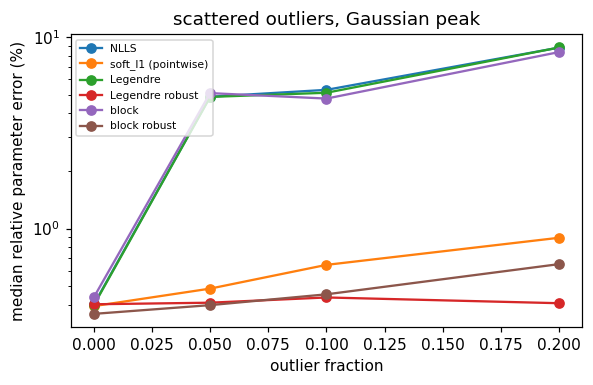

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 3.6))
for name, _ in LADDER:
    line = outlier_sweep[outlier_sweep.estimator == name].sort_values("fraction")
    ax.semilogy(line.fraction, line.param_error_pct.clip(lower=1e-3), "o-",
                label=name)
ax.set_xlabel("outlier fraction")
ax.set_ylabel("median relative parameter error (%)")
ax.legend(loc="upper left", fontsize=7)
ax.set_title("scattered outliers, Gaussian peak")
fig.tight_layout()


### Reading

At 10 percent contamination the three plain rows land within 11 percent of
each other (NLLS 5.30 percent median parameter error, Legendre 5.11, block
4.77): plain block carries no robustness of its own, it is pointwise least
squares in another basis, and it is not even reliably the worst of the
three. Claim 1 holds.

The robust rows are far below that, not merely below a third of it: robust
Legendre is 8.5 percent of plain Legendre's error at 10 percent
contamination (0.44 against 5.11), robust block 9.5 percent of plain
block's (0.45 against 4.77). Both bases turn a five-percent error into
under half a percent once the image is reweighted. Claim 2 holds, in
either basis.

At zero contamination the six rows sit inside a noise band from 0.36 to
0.44 percent, in no consistent order (block robust is the lowest row
here, not the highest): three parameters recovered from 300 points at 5
percent noise leave too little signal in the median relative error for a
reweighting cost to show. The next section reads the same clean case on a
lower-variance statistic, the fitted curve's RMSE against the truth.


In [4]:
piv = outlier_sweep.pivot(index="estimator", columns="fraction",
                           values="param_error_pct")
plain = piv.loc[["NLLS", "Legendre", "block"], 0.10]
# fails if any plain row separates from the others by more than a quarter
assert plain.max() / plain.min() <= 1.25, plain

robust_vs_plain = {
    "Legendre": piv.loc["Legendre robust", 0.10] / piv.loc["Legendre", 0.10],
    "block": piv.loc["block robust", 0.10] / piv.loc["block", 0.10],
}
# fails if a robust row is not clearly below a third of its plain counterpart
assert all(v < 1 / 3 for v in robust_vs_plain.values()), robust_vs_plain
print("plain rows at 10% contamination:", plain.to_dict())
print("robust/plain ratio at 10%:", robust_vs_plain)


plain rows at 10% contamination: {'NLLS': 5.296509039346963, 'Legendre': 5.114697356659818, 'block': 4.7696950087542795}
robust/plain ratio at 10%: {'Legendre': np.float64(0.08548869207433721), 'block': np.float64(0.09520090316928179)}


In [5]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("14_robust_image", "outlier_sweep", outlier_sweep)
    print("wrote experiments/results/14_robust_image/outlier_sweep.csv")


wrote experiments/results/14_robust_image/outlier_sweep.csv


## The burst sweep

Same family, same ladder, fraction fixed at 10 percent, `n=400` so the
contaminated count (`0.10 * 400 = 40`) exactly matches the longest run
length tried and no run is silently trimmed by `montecarlo.contaminate`.
The score changes here: median fitted-curve RMSE against the clean signal,
as a ratio to the median RMSE of plain NLLS on clean data, so the six rows
read on one scale from "no worse than clean NLLS" (1.0) upward.


In [6]:
def curve(estimate):
    return FAMILY.func(X_REF, *[estimate[k] for k in NAMES])


X_REF = np.linspace(FAMILY.span[0], FAMILY.span[1], 400)
CLEAN_REF = FAMILY.func(X_REF, *[FAMILY.truth[k] for k in NAMES])


def rmse_to_clean(estimate):
    return float(np.sqrt(np.mean((curve(estimate) - CLEAN_REF) ** 2)))


clean_base = []
for s in range(SEEDS):
    rng = np.random.default_rng(1000 + s)
    x, y, _ = draw(rng, 400, 0.05, 0.0, 1)
    clean_base.append(rmse_to_clean(est_nlls(x, y)))
BASE_RMSE = float(np.median(clean_base))
print(f"clean NLLS rmse-to-truth, median over {SEEDS} seeds: {BASE_RMSE:.5f}")

rows = []
for burst in BURSTS:
    for name, estimator in LADDER:
        ratios = []
        for s in range(SEEDS):
            rng = np.random.default_rng(s)
            x, y, _ = draw(rng, 400, 0.05, 0.10, burst)
            try:
                ratios.append(rmse_to_clean(estimator(x, y)) / BASE_RMSE)
            except Exception:
                ratios.append(np.nan)
        rows.append({"estimator": name, "burst": burst,
                      "rmse_ratio": float(np.nanmedian(ratios))})
burst_sweep = pd.DataFrame(rows)
burst_sweep.pivot(index="estimator", columns="burst",
                   values="rmse_ratio").loc[[n for n, _ in LADDER]]


clean NLLS rmse-to-truth, median over 30 seeds: 0.01616


burst,1,5,10,20,40
estimator,,,,,
NLLS,16.416339,17.256068,15.064038,17.282273,8.652581
soft_l1 (pointwise),1.962017,1.901795,1.679330,2.637991,1.530237
Legendre,16.598753,17.034907,15.031074,17.544348,8.777579
Legendre robust,1.180024,1.194793,1.180165,1.345287,1.321463
block,16.983330,16.795693,14.414529,17.467315,8.252988
block robust,1.201376,1.558258,2.140044,3.928914,3.497736


### Reading

The three plain rows again move together, from about 15 to 17 times the
clean-NLLS curve RMSE at bursts 1, 5, 10 and 20, dropping to about 8.7
times at burst 40 (a single 40-sample gash is, at this sample size, no
worse for an unweighted fit than the same count spread thin). `soft_l1`
holds close to twice the clean baseline throughout, with no clear trend
in the run length.

The two reweighted routes separate. Robust Legendre stays flat, 1.18 to
1.35 across every burst length tried, 1.32 at the longest. Robust block
starts level with it at burst 1 (1.20) and climbs to 3.93 at burst 20
before easing to 3.50 at burst 40; it grows 2.9 times from the shortest
burst to the longest against Legendre's 1.1 times. The mechanism is the
one the next section isolates: a long contiguous run starts to fill whole
windows of the block basis, and reweighting inside a window that is
mostly outliers has nothing clean left to reweight toward.


In [7]:
bpiv = burst_sweep.pivot(index="estimator", columns="burst", values="rmse_ratio")
block_growth = bpiv.loc["block robust", BURSTS[-1]] / bpiv.loc["block robust", BURSTS[0]]
legendre_growth = (bpiv.loc["Legendre robust", BURSTS[-1]]
                    / bpiv.loc["Legendre robust", BURSTS[0]])
# fails if the robust block fit does not degrade faster than robust Legendre
# as the outlier run lengthens
assert block_growth > legendre_growth, (block_growth, legendre_growth)
print(f"robust block grows {block_growth:.2f}x from burst {BURSTS[0]} to "
      f"{BURSTS[-1]}, robust Legendre {legendre_growth:.2f}x")


robust block grows 2.91x from burst 1 to 40, robust Legendre 1.12x


In [8]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("14_robust_image", "burst_sweep", burst_sweep)
    print("wrote experiments/results/14_robust_image/burst_sweep.csv")


wrote experiments/results/14_robust_image/burst_sweep.csv


## Why the block basis loses a burst

Fixing the robust block fit's window count at 4, 8, 16 and 48, at the
shortest burst (a scattered run of 1) and the longest (40, the whole
contaminated run in one block), against the robust Legendre fit at order
12 as a reference that does not depend on a window count. Alongside: how
many of the basis's own windows end up more than half contaminated,
counted on the same contamination draws from their index ranges rather
than by re-running `BlockBasis`, and averaged over the seed block.

Every number here is a median over a seed block of a ratio of medians, and
it moves with the block, so the long-burst comparison is then repeated over
disjoint seed blocks and the check reads all of them rather than the one
the table is drawn from.

In [9]:
def windows_over_half(idx, n, k):
    edges = np.linspace(0, n, k + 1)
    count = 0
    for lo, hi in zip(edges[:-1], edges[1:]):
        width = hi - lo
        hit = np.sum((idx >= lo) & (idx < hi))
        if hit > width / 2:
            count += 1
    return count


rows = []
for burst in (BURSTS[0], BURSTS[-1]):
    draws = [draw(np.random.default_rng(s), 400, 0.05, 0.10, burst)
             for s in range(SEEDS)]
    leg_ratios = []
    for x, y, idx in draws:
        try:
            leg_ratios.append(rmse_to_clean(est_dt(x, y, "legendre", LEG_ORDER, True))
                              / BASE_RMSE)
        except Exception:
            leg_ratios.append(np.nan)
    leg_ratio = float(np.nanmedian(leg_ratios))
    for k in WINDOW_COUNTS:
        ratios, halves = [], []
        for x, y, idx in draws:
            halves.append(windows_over_half(idx, 400, k))
            try:
                ratios.append(rmse_to_clean(est_dt(x, y, "block", k, True))
                              / BASE_RMSE)
            except Exception:
                ratios.append(np.nan)
        rows.append({"K": k, "burst": burst,
                      "block_robust_ratio": float(np.nanmedian(ratios)),
                      "windows_half_contaminated": float(np.mean(halves)),
                      "legendre_robust_ratio": leg_ratio})
window_count = pd.DataFrame(rows)
window_count


,K,burst,block_robust_ratio,windows_half_contaminated,legendre_robust_ratio
0,4,1,2.764688,0.000000,1.180024
1,8,1,1.684199,0.000000,1.180024
2,16,1,1.423440,0.000000,1.180024
3,48,1,1.201376,0.000000,1.180024
4,4,40,4.776914,0.000000,1.321463
5,8,40,1.438850,0.866667,1.321463
6,16,40,1.882045,1.633333,1.321463
7,48,40,3.497736,4.866667,1.321463


In [10]:
clean_by_k = {}
for k in WINDOW_COUNTS:
    rmses = []
    for s in range(SEEDS):
        rng = np.random.default_rng(s)
        x, y, _ = draw(rng, 400, 0.05, 0.0, 1)
        try:
            rmses.append(rmse_to_clean(est_dt(x, y, "block", k, True)))
        except Exception:
            rmses.append(np.nan)
    clean_by_k[k] = float(np.nanmedian(rmses))
print("robust block curve RMSE on clean data, by window count:",
      {k: f"{v:.4f}" for k, v in clean_by_k.items()})

robust block curve RMSE on clean data, by window count: {4: '0.0229', 8: '0.0168', 16: '0.0155', 48: '0.0156'}


In [11]:
def burst40_by_window(offset):
    base = []
    for s in range(SEEDS):
        x, y, _ = draw(np.random.default_rng(1000 + offset + s), 400, 0.05, 0.0, 1)
        base.append(rmse_to_clean(est_nlls(x, y)))
    ref = float(np.median(base))
    draws = [draw(np.random.default_rng(offset + s), 400, 0.05, 0.10, BURSTS[-1])
             for s in range(SEEDS)]

    def median_ratio(basis, order):
        out = []
        for x, y, _ in draws:
            try:
                out.append(rmse_to_clean(est_dt(x, y, basis, order, True)) / ref)
            except Exception:
                out.append(np.nan)
        return float(np.nanmedian(out))

    return (median_ratio("legendre", LEG_ORDER),
            {k: median_ratio("block", k) for k in WINDOW_COUNTS})


SEED_BLOCKS = [b * SEEDS for b in range(2 if QUICK else 4)]
by_block = {off: burst40_by_window(off) for off in SEED_BLOCKS}
for off, (leg, blk) in by_block.items():
    print(f"seeds {off}-{off + SEEDS - 1} at burst {BURSTS[-1]}: "
          f"Legendre {leg:.2f}, block "
          + ", ".join(f"K={k} {v:.2f}" for k, v in blk.items()))


seeds 0-29 at burst 40: Legendre 1.32, block K=4 4.78, K=8 1.44, K=16 1.88, K=48 3.50
seeds 30-59 at burst 40: Legendre 1.34, block K=4 3.94, K=8 1.85, K=16 3.52, K=48 3.91
seeds 60-89 at burst 40: Legendre 0.88, block K=4 3.28, K=8 1.25, K=16 1.07, K=48 1.36
seeds 90-119 at burst 40: Legendre 0.96, block K=4 4.21, K=8 1.70, K=16 3.44, K=48 5.40


### Reading

At the shortest burst (scattered single-sample outliers) the robust block
fit improves steadily with more windows, 2.76 at 4 windows down to 1.20 at
48, closing in on robust Legendre's 1.18 but never passing it: more
windows give the per-window reweighting more places to isolate an
outlier. At the longest burst it is not monotonic: 4.78 at 4 windows, 1.44
at 8, 1.88 at 16, 3.50 at 48, against Legendre's 1.32 throughout. No
window count catches Legendre under the long burst; claim 3 holds.

Those are one 30-seed block's numbers, and at burst 40 a median of per-seed
ratios moves a long way with the block. Over the four disjoint blocks the
48-window ratio runs 1.36 to 5.40, the 16-window ratio 1.07 to 3.52, the
8-window ratio 1.25 to 1.85, the 4-window ratio 3.28 to 4.78 and robust
Legendre 0.88 to 1.34: the size of the gap is not measured to the three
figures the table prints it in. What does hold in every block is the
ordering the claim is about, every window count above robust Legendre, and
the check reads all four blocks rather than the one the table is drawn
from.

The `windows_half_contaminated` column names the mechanism at the narrow
end: at burst 40, 48 windows of width 8.3 samples put close to five whole
windows more than half outliers, 4.9 of them on average over the 30 draws,
and a window that is mostly contamination has nothing clean inside it left
to reweight toward; at 16 windows (width 25) the average is under two
windows, 1.6; at 8 and 4 windows (width 50 and 100) no window crosses the
half mark, since 40 contaminated samples are under half of even the
narrowest of those. The worst row
(4 windows) is not explained by that count at all: with only 4 windows a
block fit is already coarse on this peak on clean data, where the same
robust block fit has a median curve RMSE of 0.0229 against 0.0168 at 8
windows and 0.0155 at 16, and that resolution limit, not the burst, is
most of what is being measured there.

In [12]:
short = window_count[window_count.burst == BURSTS[0]].set_index("K").block_robust_ratio
long_ = window_count[window_count.burst == BURSTS[-1]].set_index("K").block_robust_ratio
leg_short = window_count[window_count.burst == BURSTS[0]].legendre_robust_ratio.iloc[0]
leg_long = window_count[window_count.burst == BURSTS[-1]].legendre_robust_ratio.iloc[0]
# fails if any window count's robust block fit matches or beats the robust
# Legendre fit under the longest burst, in any of the seed blocks
for off, (leg, blk) in by_block.items():
    assert min(blk.values()) > leg, (off, blk, leg)
print(f"burst {BURSTS[0]}: block by K {short.to_dict()}, Legendre {leg_short:.2f}")
print(f"burst {BURSTS[-1]}: block by K {long_.to_dict()}, Legendre {leg_long:.2f}")


burst 1: block by K {4: 2.764687940063918, 8: 1.6841985588144377, 16: 1.423440267055963, 48: 1.2013758668902312}, Legendre 1.18
burst 40: block by K {4: 4.776913791224594, 8: 1.4388503037885894, 16: 1.8820452099160367, 48: 3.497736132720213}, Legendre 1.32


In [13]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("14_robust_image", "window_count", window_count)
    print("wrote experiments/results/14_robust_image/window_count.csv")


wrote experiments/results/14_robust_image/window_count.csv


## The price of reweighting on clean data

The zero-contamination case on its own, on the curve-RMSE scale of the
burst sweep rather than the parameter-error scale of the scattered sweep:
at 300 clean samples the median relative parameter error of a
three-parameter fit moves a few tenths of a percent from estimator to
estimator in no order, so that scale cannot price reweighting at all. The
price is read here as the ratio of pooled curve RMSE, the root mean square
over a block's draws, of the robust fit to the plain fit in the same
basis. Five disjoint blocks of 60 clean draws, so the block-to-block
movement of that ratio is measured beside it, together with how many of
the 60 draws put the robust fit above the plain one.


In [14]:
COST_SEEDS = 8 if QUICK else 60
COST_BLOCKS = [b * COST_SEEDS for b in range(2 if QUICK else 5)]


def clean_rmse_block(offset):
    out = {name: [] for name, _ in LADDER}
    for s in range(offset, offset + COST_SEEDS):
        x, y, _ = draw(np.random.default_rng(s), 400, 0.05, 0.0, 1)
        for name, estimator in LADDER:
            try:
                out[name].append(rmse_to_clean(estimator(x, y)))
            except Exception:
                out[name].append(np.nan)
    return {name: np.asarray(v) for name, v in out.items()}


def pooled(values):
    return float(np.sqrt(np.nanmean(np.asarray(values) ** 2)))


clean_blocks = {off: clean_rmse_block(off) for off in COST_BLOCKS}
rows = []
for off, per in clean_blocks.items():
    row = {"seed_block": off}
    for basis in ("Legendre", "block"):
        plain_rmse, robust_rmse = per[basis], per[f"{basis} robust"]
        row[f"{basis} cost"] = pooled(robust_rmse) / pooled(plain_rmse)
        row[f"{basis} draws above one"] = int(np.sum(robust_rmse > plain_rmse))
    rows.append(row)
reweight_cost = pd.DataFrame(rows)
reweight_cost.round(3)


,seed_block,Legendre cost,Legendre draws above one,block cost,block draws above one
0,0,1.015,32,1.032,37
1,60,1.029,30,1.038,34
2,120,1.007,35,0.999,30
3,180,1.014,28,1.021,32
4,240,1.040,35,1.061,35


In [15]:
first_block = clean_blocks[COST_BLOCKS[0]]
clean_ratio = pd.Series({name: pooled(first_block[name])
                         / pooled(first_block["NLLS"])
                         for name, _ in LADDER})
print(f"clean-data pooled curve RMSE over {COST_SEEDS} draws, as a ratio to "
      f"plain NLLS on the same draws:")
print(clean_ratio.round(4).to_string())


clean-data pooled curve RMSE over 60 draws, as a ratio to plain NLLS on the same draws:
NLLS                   1.0000
soft_l1 (pointwise)    0.9997
Legendre               0.9996
Legendre robust        1.0150
block                  0.9967
block robust           1.0288


### Reading

On clean data the six rows sit on top of each other on this scale: pooled
over the same 60 draws and read against plain NLLS, pointwise soft_l1 is at
0.9997, the plain Legendre image at 0.9996, the plain block image at
0.9967, and the two robust rows at 1.0150 and 1.0288. The price of
reweighting is the ratio inside a basis, and five blocks of 60 draws do not
resolve it: it runs 1.007 to 1.040 in the Legendre basis and 0.999 to 1.061
in the block basis, while 28 to 35 of a block's 60 draws put the robust
Legendre fit above the plain one and 30 to 37 do for block. Inside one
block, half the draws either way is what no difference looks like. Across
the blocks the ratio is above one in all five for Legendre and in four of
five for block, the fifth reading 0.999, so the price has a sign and no
sharper size than a few percent. Claim 4 holds: reweighting costs at most a
few percent of curve RMSE where there is nothing to reweight against.


In [16]:
cost_cols = ["Legendre cost", "block cost"]
if QUICK:
    print("QUICK: the reweighting cost needs the full seed blocks")
else:
    # fails if reweighting degrades a clean fit instead of costing a few
    # percent of it: a robust route crippled to order 3 lands above 1.15
    assert reweight_cost[cost_cols].max().max() <= 1.15, reweight_cost
for basis in ("Legendre", "block"):
    cost = reweight_cost[f"{basis} cost"]
    above = reweight_cost[f"{basis} draws above one"]
    print(f"{basis}: pooled robust over plain curve RMSE {cost.min():.3f} to "
          f"{cost.max():.3f} over {len(reweight_cost)} blocks, "
          f"{above.min()} to {above.max()} of {COST_SEEDS} draws above one")


Legendre: pooled robust over plain curve RMSE 1.007 to 1.040 over 5 blocks, 28 to 35 of 60 draws above one
block: pooled robust over plain curve RMSE 0.999 to 1.061 over 5 blocks, 30 to 37 of 60 draws above one


In [17]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("14_robust_image", "reweight_cost", reweight_cost)
    print("wrote experiments/results/14_robust_image/reweight_cost.csv")


wrote experiments/results/14_robust_image/reweight_cost.csv


## Findings, limits and provenance

The plain block fit has no robustness of its own: at 10 percent scattered
contamination it tracks plain NLLS and plain Legendre within 11 percent
(4.77 against 5.30 and 5.11 percent median parameter error), because it is
the same unweighted least squares in a different basis. Reweighting the
image, in either basis, is what carries the robustness: at the same 10
percent it drops the error to under a tenth of the plain fit's, 0.44 and
0.45 percent against 5.11 and 4.77. Reweighting is close to free on clean
data: over five disjoint blocks of 60 clean draws the robust fit's pooled
curve RMSE is 1.007 to 1.040 times the plain fit's in the Legendre basis
and 0.999 to 1.061 times in the block basis, with 28 to 37 of a block's 60
draws above one, so the price is a few percent at most, above one in nine
of the ten block ratios and inside any one block not separated from no price
at all. The parameter-error scale of the scattered sweep is coarser still
and does not order the clean rows.

The burst result is a mechanism, not a ranking. Robust Legendre is flat
across run lengths 1 to 40 (1.18 to 1.35 times the clean-NLLS curve RMSE);
robust block grows 2.9 times over the same range and, on the seed block the
table is drawn from, reaches 3.5 times at 48 windows against Legendre's
1.3. No window count tried (4, 8, 16, 48) beats Legendre once the burst is
long, in any of the four seed blocks, and the reason is countable: at burst
40, 48 narrow windows put 4.9 of them on average more than half outliers,
where a per-window reweight has no clean data left inside the window to
fall back on. Coarser windows do not fix this by avoiding it: at 4 windows
the block fit is already the worst row under the long burst, but that is
mostly the coarse basis's own resolution limit on this peak (clean curve
RMSE 0.0229 at 4 windows against 0.0155 to 0.0168 from 8 up), not the
outliers. That block is the worst row at every window count is false;
claim 3 is the narrower statement.

Limits: one family (the Gaussian peak), one contamination magnitude (8
sigma of the noisy signal's own scale), one set of orders (Legendre 12,
block 48 as the fixed ladder members, 4/8/16/48 where block's order
varies) and one sample count per section. The long-burst numbers carry seed
scatter of the same size as the effect they show: over the four 30-seed
blocks the 48-window ratio at burst 40 spans 1.36 to 5.40 and robust
Legendre 0.88 to 1.34, so "3.5 against 1.3" is one block's reading of an
ordering that survives all four, not a constant. Burst placement relative
to the window grid is not varied here: a run positioned to straddle a
window boundary rather than sit inside one window is not measured.

In [18]:
print(notebook.provenance(STARTED))

2026-09-21 commit 307f7bb dtfit 0.4.0 dtfit-experimental 0.1.0 22.4s
